In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [3]:
df=pd.read_csv(os.getenv("cleaned_df_path"))

***Rechecking the cleaned data***

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-nu

In [6]:
df.isnull().sum().sum()   #no null values

np.int64(0)

In [7]:
df.duplicated().sum() #no duplicates

np.int64(0)

In [8]:
df["Class"].value_counts() #imbalanced dataset

Class
0    283253
1       473
Name: count, dtype: int64

***Univariate Analysis***

***Histogram to understand class distribution***

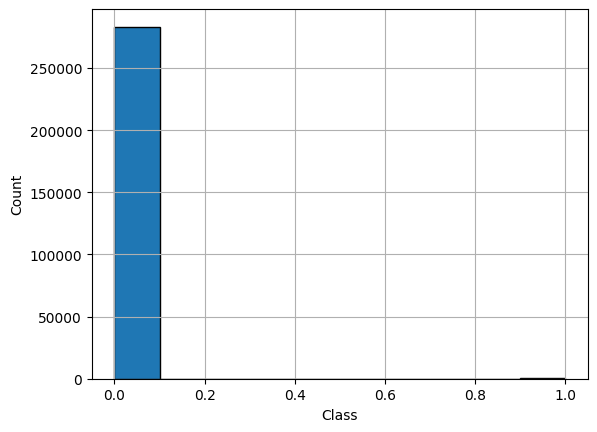

In [9]:
df["Class"].hist(edgecolor="black")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
# Highly Imbalanced dataset with 0's being the majority class and 1's being the minority class.
# This is a common scenario in fraud detection where fraudulent transactions are much less frequent than legitimate ones.

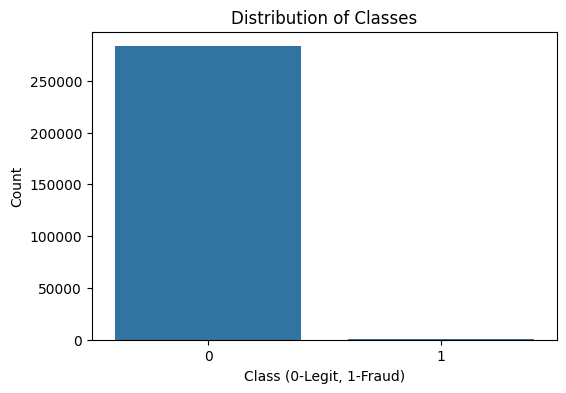

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Class")
plt.title("Distribution of Classes")
plt.xlabel("Class (0-Legit, 1-Fraud)")
plt.ylabel("Count")
plt.show()

***Boxplot to understand Amount distrubution***

In [12]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

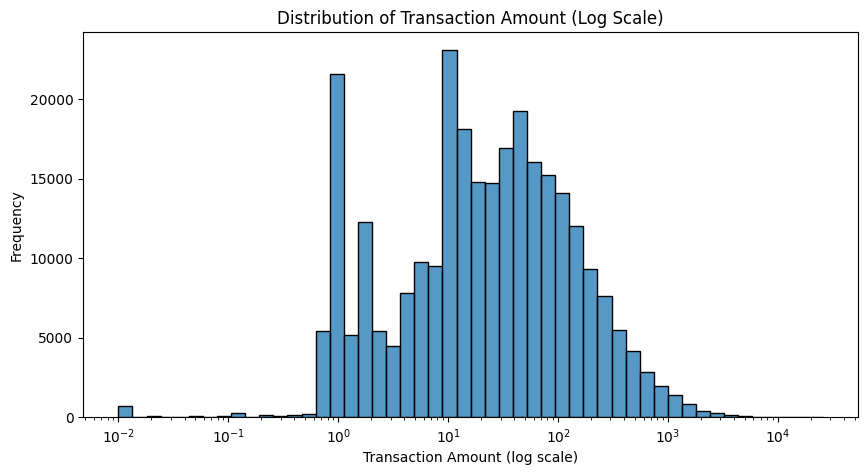

In [62]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=50, log_scale=True)
plt.title("Distribution of Transaction Amount (Log Scale)")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Frequency")
plt.show()

The raw transaction amount distribution is extremely right-skewed, with the overwhelming majority of transactions falling under $500 and a small number of high-value outliers (up to ~$25,000) stretching the axis. A log-scale transformation is needed to meaningfully visualize the shape of the bulk distribution.

<Axes: xlabel='Class', ylabel='Amount'>

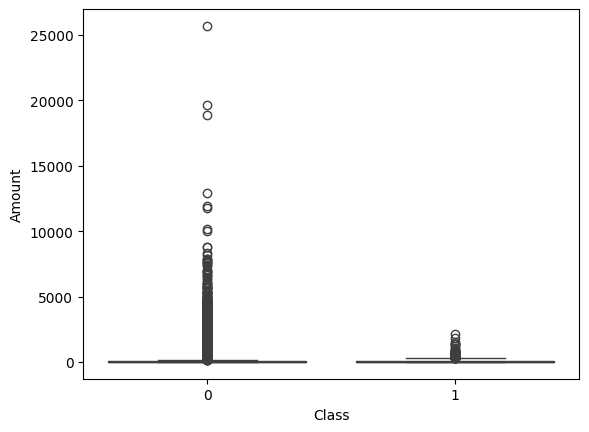

In [14]:
sns.boxplot(x="Class",y="Amount",data=df)

Legit transactions exhibit a wider range of amounts including several high value outliers while fraudulent transactions are
consistently capped at much lower amounts

***Class Percentages***

In [15]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


the dataset is extremely imbalanced
fraudulent transactions account for only 0.17 percent of all records

# Amount - Univaruate Analysis

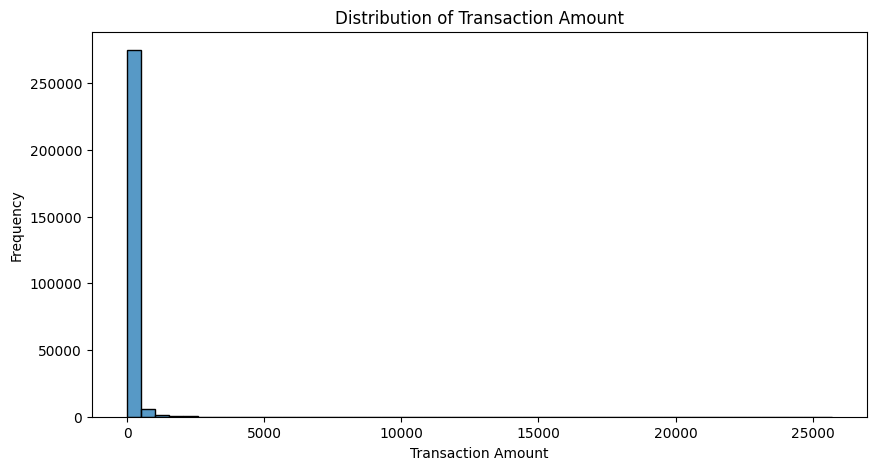

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

extremely right skewed

**Amount - Boxplot**

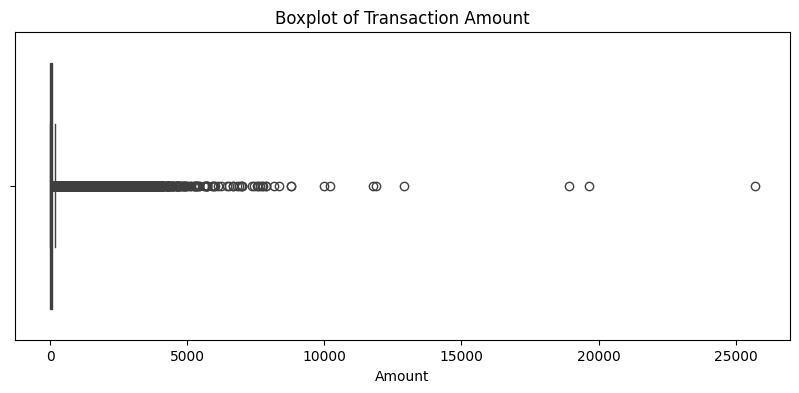

In [19]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")
plt.xlabel("Amount")

plt.show()

A few outliers/extreme vals can be spotted

# Time - Univariate Analysis

In [23]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

**Time Distribution**

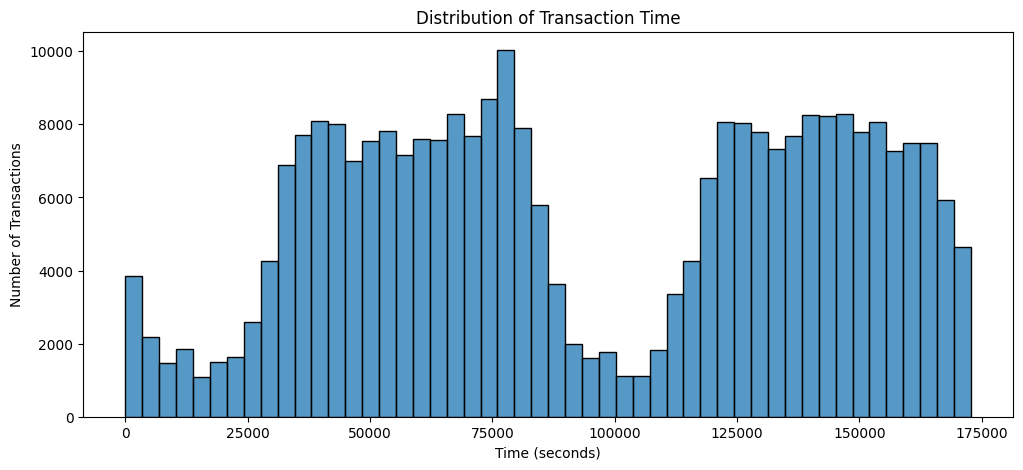

In [24]:
plt.figure(figsize=(12, 5))

sns.histplot(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")

plt.show()

volume dips sharply overnight and rises through the day,
peaks midday before tapering again

In [25]:
# converting time to hours
df["Hour"] = (df["Time"] / 3600) % 24

In [26]:
df["Hour"].describe()

count    283726.000000
mean         14.537139
std           5.846094
min           0.000000
25%          10.597500
50%          15.008889
75%          19.329167
max          23.999444
Name: Hour, dtype: float64

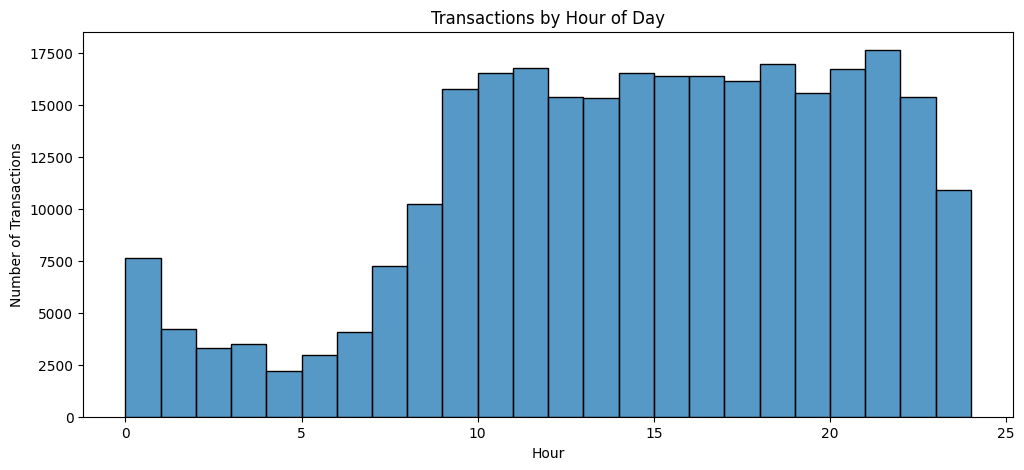

In [27]:
plt.figure(figsize=(12, 5))

sns.histplot(df["Hour"], bins=24)

plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()

Transaction volume is lowest between 1 AM–6 AM and stays consistently high from 9 AM–11 PM, peaking slightly around 9 PM. This overnight dip reflects normal transaction behavior and sets a baseline to compare against fraud rate by hour.

# V1-V28 - Univariate Analysis

In [30]:
v_features = [f"V{i}" for i in range(1, 29)]

df[v_features].describe().T

,count,mean,std,min,25%,50%,75%,max
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995
V10,283726.0,-0.001441,1.076407,-24.588262,-0.535578,-0.093237,0.453619,23.745136


## Bivariate Analysis

**Transaction Amount vs Class**

In [37]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


Legit transactions (Class 0, n=283,253) have mean $88.41 but median only $22, heavily right-skewed with a $25,691 max outlier. Fraud transactions (Class 1, n=473) show even more skew (mean $123.87 vs median $9.82) and severe class imbalance (~0.17% of data)

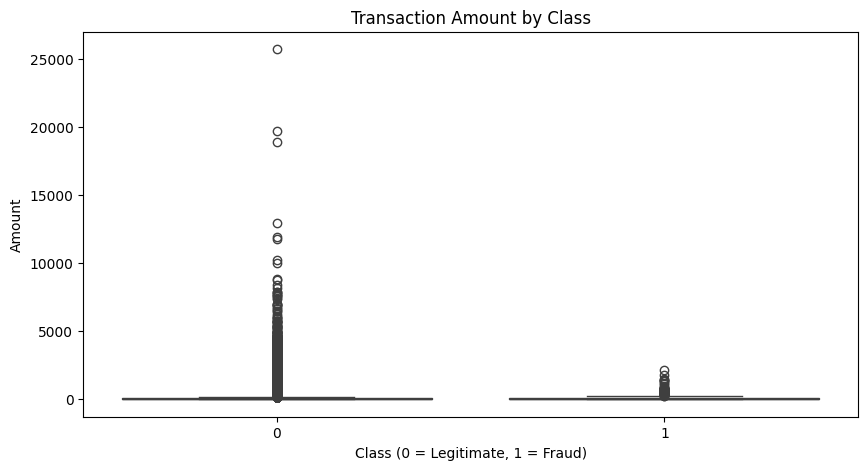

In [38]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

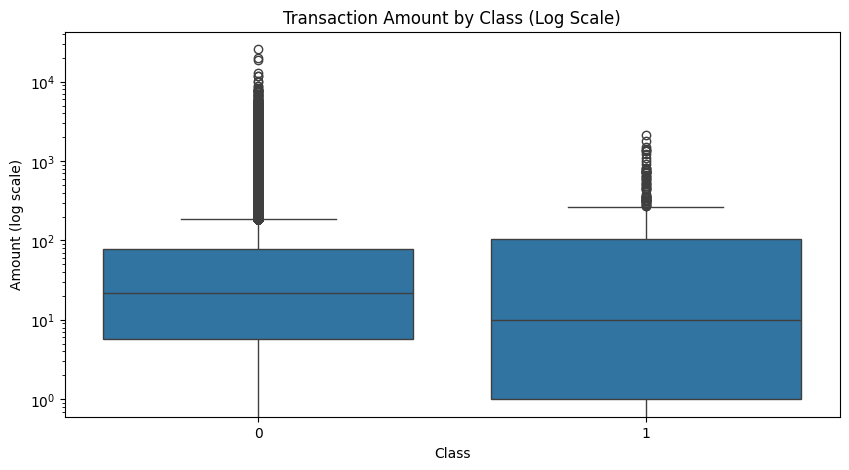

In [39]:
# using a log scale since extreme values are dominating the plot
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.yscale("log")

plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Amount (log scale)")

plt.show()

both classes show tons of outliers outside of their box. Fraud transactions (Class 1) show a wider interquartile range and higher median (~$10) than legit ones (~$22 median but tighter box), while legit transactions have far more extreme outliers, reaching up to ~$25k versus fraud's ~$2k cap. The log scale reveals that despite fraud being rarer, its amounts are more variably distributed, a pattern worth flagging as a potential feature for the model.

**Fraud Rate by Transaction Amount**

In [40]:
df["Amount_Bin"] = pd.qcut(
    df["Amount"],
    q=10,
    duplicates="drop"
)

In [41]:
fraud_by_amount = (
    df.groupby("Amount_Bin", observed=True)["Class"]
      .agg(["count", "sum", "mean"])
)

fraud_by_amount

,count,sum,mean
Amount_Bin,,,
"(-0.001, 1.0]",30331,171,0.005638
"(1.0, 3.58]",26662,26,0.000975
"(3.58, 8.92]",28222,36,0.001276
"(8.92, 13.04]",28276,13,0.000460
"(13.04, 22.0]",28484,14,0.000492
"(22.0, 37.07]",28271,16,0.000566
"(37.07, 59.9]",28521,23,0.000806
"(59.9, 100.0]",28560,49,0.001716
"(100.0, 203.38]",28027,43,0.001534


fraud rate isn't evenly spread across amount ranges, it's highest in the lowest bin ($0–$1, fraud rate 0.56%) and the highest bin ($203–$25.6k, fraud rate 0.29%), forming a U-shaped pattern. Mid-range transactions ($9–$60) have the lowest fraud rates (~0.05–0.08%), suggesting fraudsters may favor either very small (testing stolen cards) or very large (cashing out) transaction amounts.

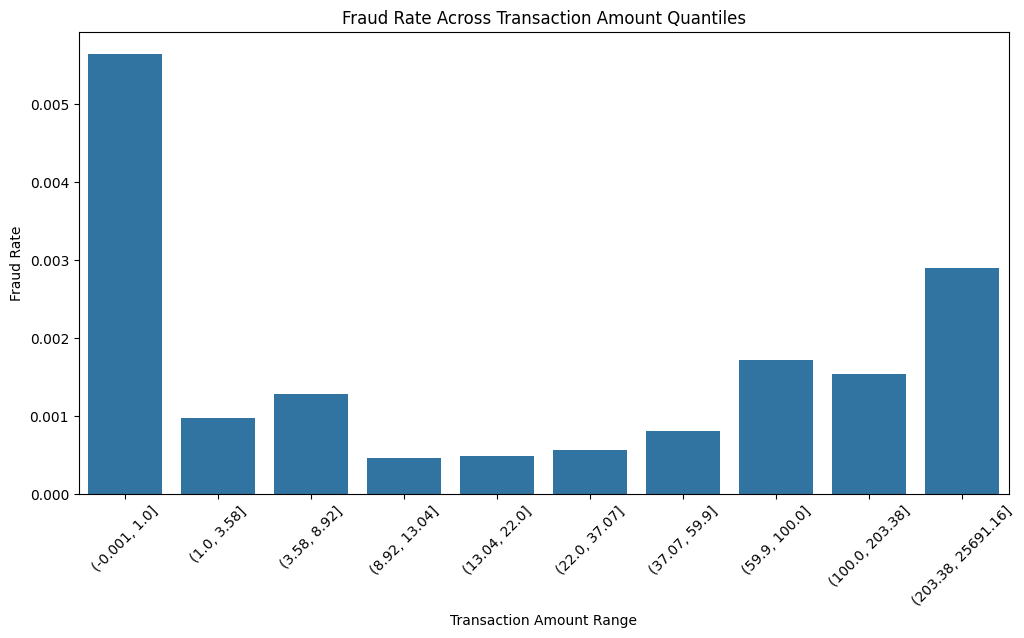

In [42]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=fraud_by_amount.reset_index(),
    x="Amount_Bin",
    y="mean"
)

plt.title("Fraud Rate Across Transaction Amount Quantiles")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)

plt.show()

there's a clear U-shaped pattern. Fraud rate is highest for very small transactions ($0–$1, ~0.56%), drops to its lowest point in the mid-range ($9–$22, ~0.05%), then climbs back up for large transactions ($203+, ~0.29%). This suggests fraudsters may test stolen cards with tiny transactions and then cash out with larger ones, while genuine mid-sized purchases are comparatively safer, making Amount a potentially useful feature for the model.

**Fraud Rate by Hour**

In [44]:
fraud_by_hour = (
    df.groupby(df["Hour"].astype(int))["Class"]
      .agg(["count", "sum", "mean"])
)

fraud_by_hour.T

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,7647.000000,4208.000000,3308.00000,3487.000000,2204.000000,2988.000000,4082.000000,7233.00000,10232.00000,15767.000000,...,16520.000000,16374.000000,16396.000000,16130.000000,16959.000000,15566.000000,16705.000000,17629.000000,15378.000000,10883.000000
sum,6.000000,10.000000,48.00000,17.000000,23.000000,11.000000,9.000000,23.00000,9.00000,16.000000,...,23.000000,26.000000,22.000000,28.000000,28.000000,19.000000,18.000000,16.000000,9.000000,17.000000
mean,0.000785,0.002376,0.01451,0.004875,0.010436,0.003681,0.002205,0.00318,0.00088,0.001015,...,0.001392,0.001588,0.001342,0.001736,0.001651,0.001221,0.001078,0.000908,0.000585,0.001562


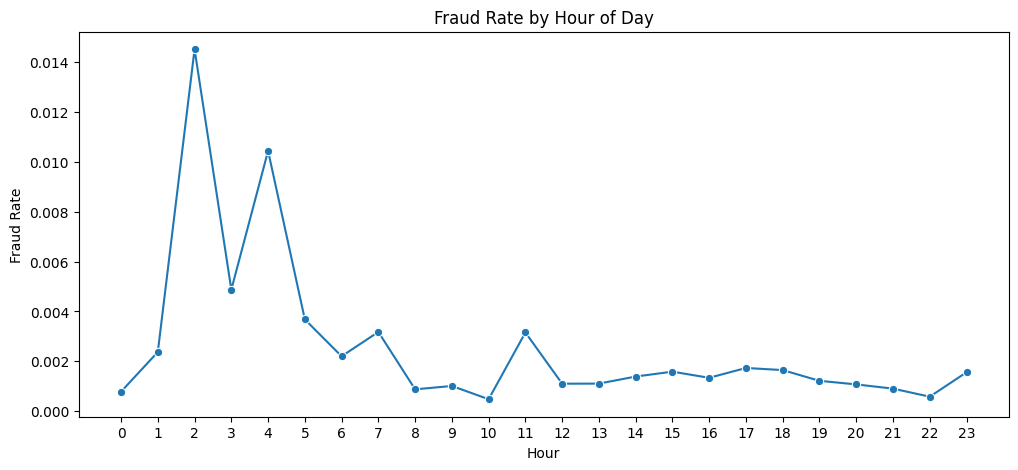

In [45]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour["mean"],
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")

plt.xticks(range(24))

plt.show()

fraud rate spikes sharply during early morning hours (2 AM–4 AM), peaking around 1.45% at 2 AM. This makes sense since legitimate transaction volume is low overnight, so fraudulent activity makes up a much larger share making Hour a strong candidate feature for the model

# Correlation Analysis

In [48]:
correlation_matrix = df.corr(numeric_only=True)

**Correlation Heatmap**

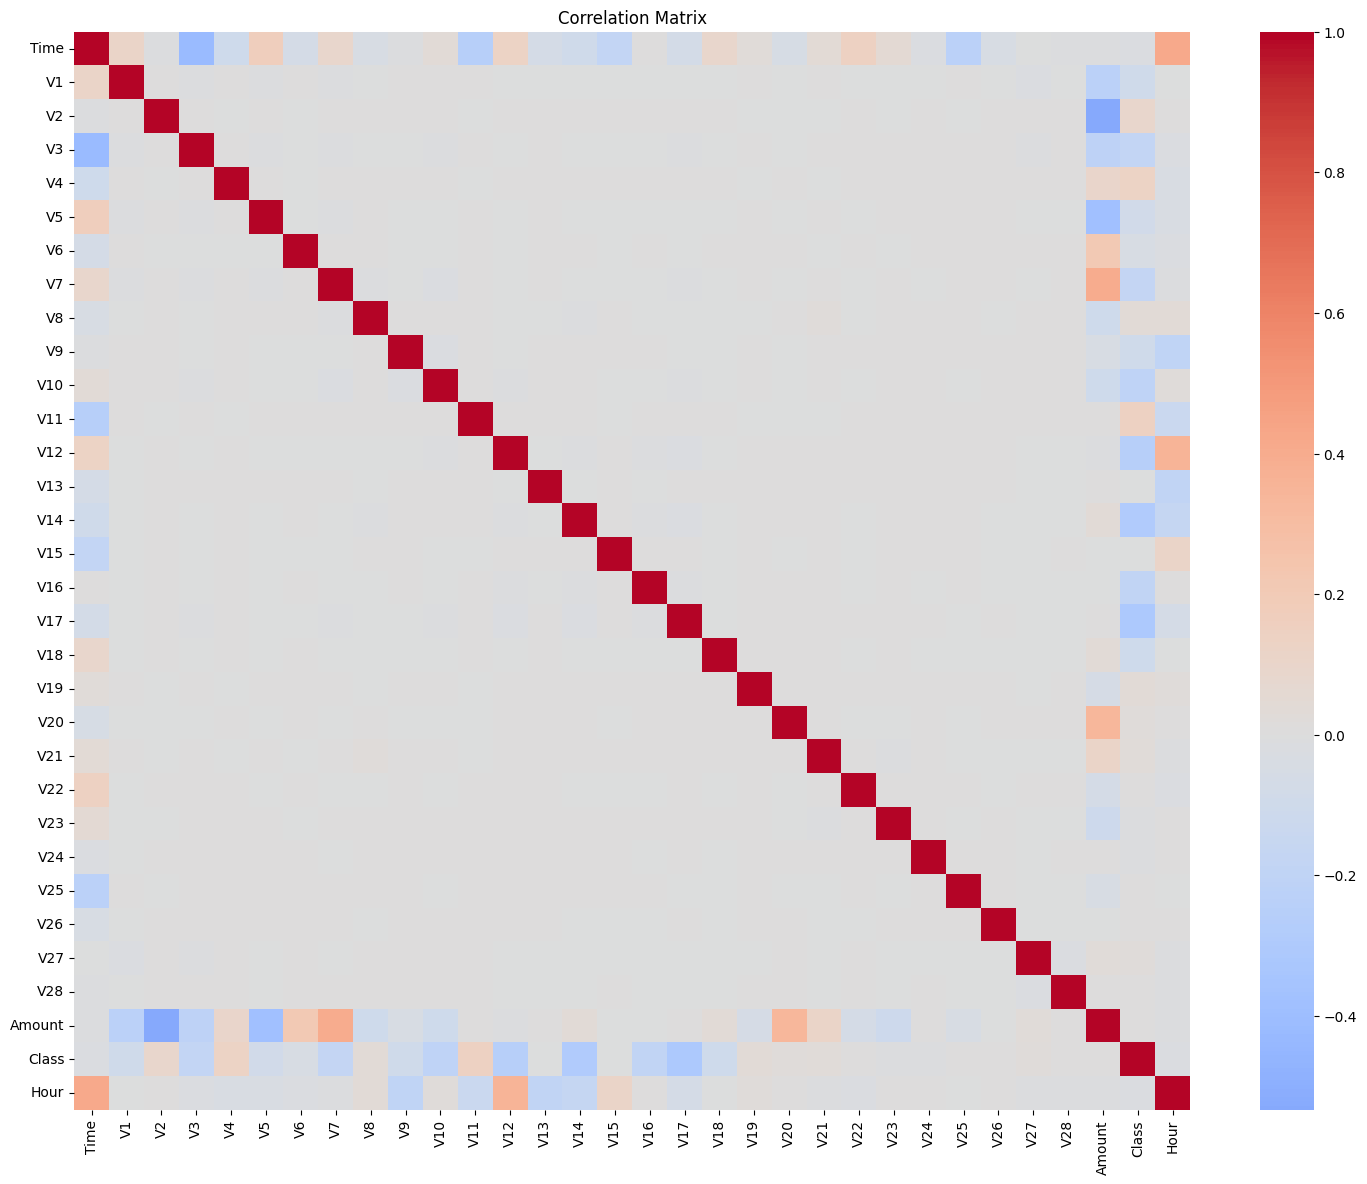

In [49]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

This heatmap shows pairwise correlations between all features — dark red = strong positive, dark blue = strong negative, and near-white/grey = little to no correlation

the diagonal is dark red (1.0) since each variable perfectly correlates with itself, but almost everything else is close to zero — expected, since V1–V28 are PCA-transformed components, which are mathematically designed to be uncorrelated with each other. The Class row/column shows only weak correlations with individual features (strongest being V17, V14, V12, V10 in the negative direction), meaning no single feature cleanly separates fraud from non-fraud, this is why models need to combine multiple features rather than rely on one strong predictor.

**Correlation with Fraud**

In [54]:
class_correlation = (
    correlation_matrix["Class"]
    .drop("Class")
    .sort_values()
)

class_correlation.T

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Hour     -0.016696
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Name: Class, dtype: float64

no feature individually predicts fraud well on its own, but V17, V14, V12, and V10 stand out as the most informative single predictors

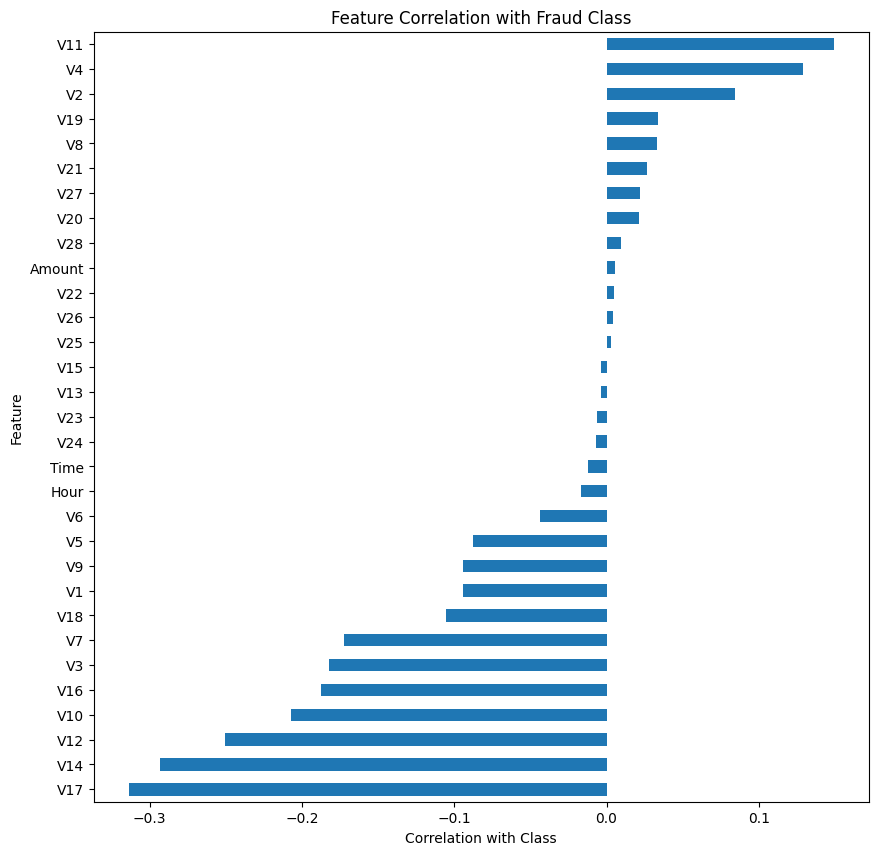

In [55]:
plt.figure(figsize=(10, 10))

class_correlation.plot(kind="barh")

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

In [ ]:
class_correlation.abs().sort_values(ascending=False).head(10)
# v17 has the highest positive correlation with the fraud class
# These features may be important for building a predictive model for fraud detection.

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

**Top Correlated Features vs Class**

In [57]:
top_corr_features = (
    class_correlation.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
)

top_corr_features

Index(['V17', 'V14', 'V12', 'V10', 'V16', 'V3'], dtype='str')

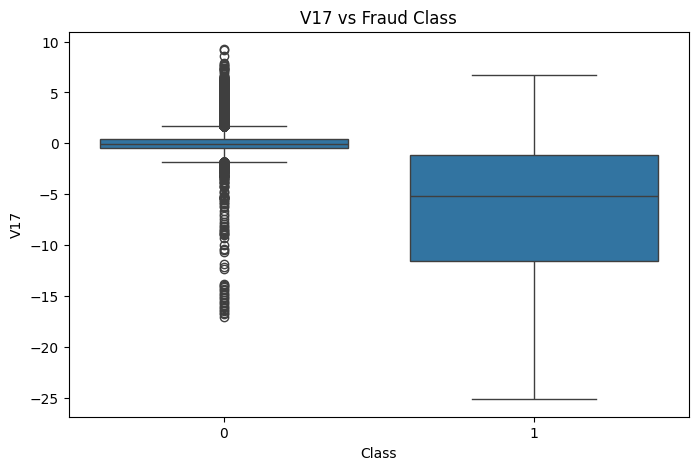

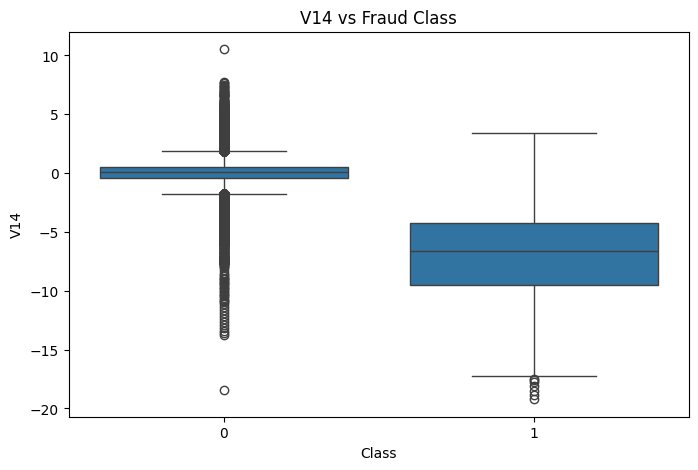

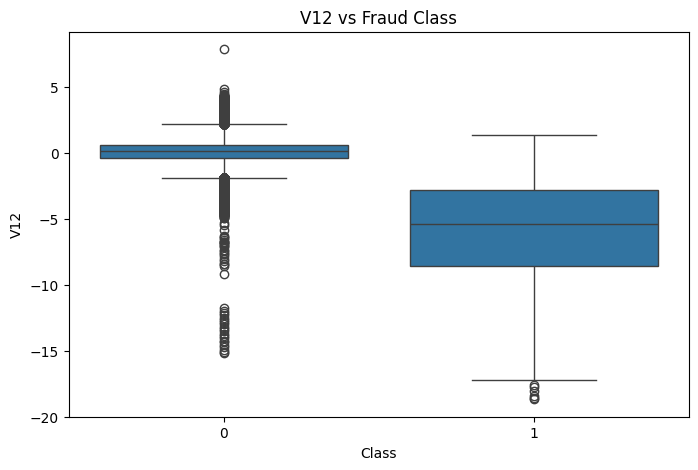

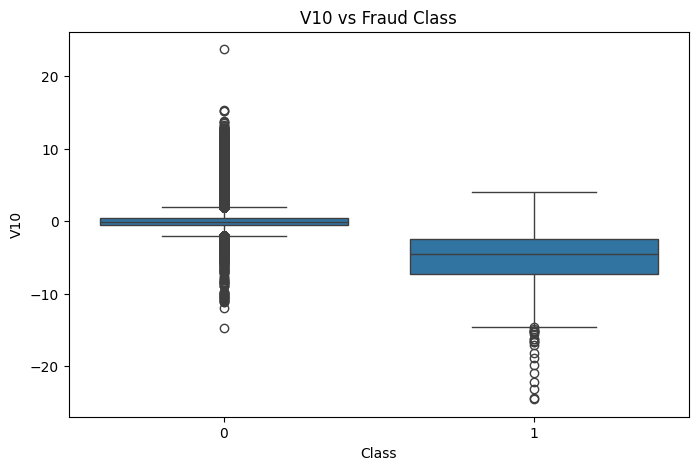

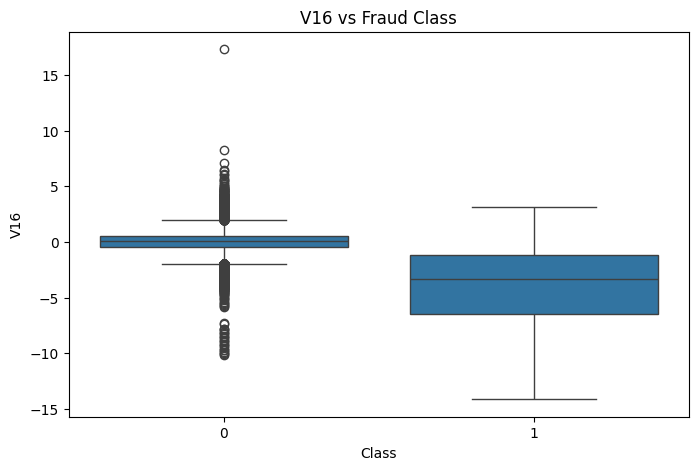

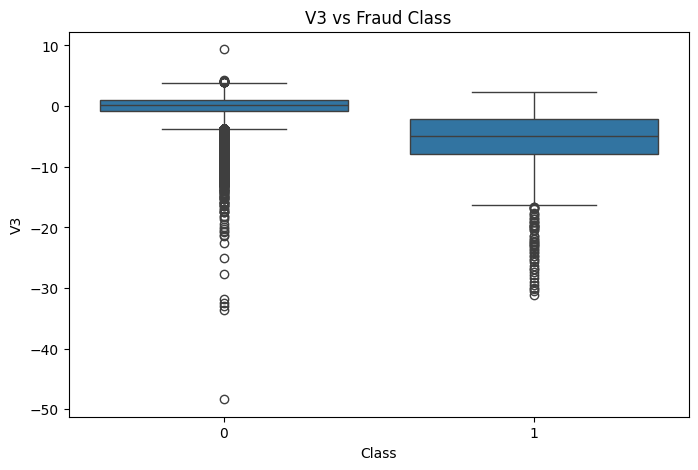

In [58]:
for feature in top_corr_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.title(f"{feature} vs Fraud Class")
    plt.xlabel("Class")
    plt.ylabel(feature)

    plt.show()

**Pairplot of Important Features**

In [59]:
pair_features = list(top_corr_features[:4]) + ["Class"]

In [60]:
pairplot_sample = df.sample(
    n=min(10000, len(df)),
    random_state=42
)

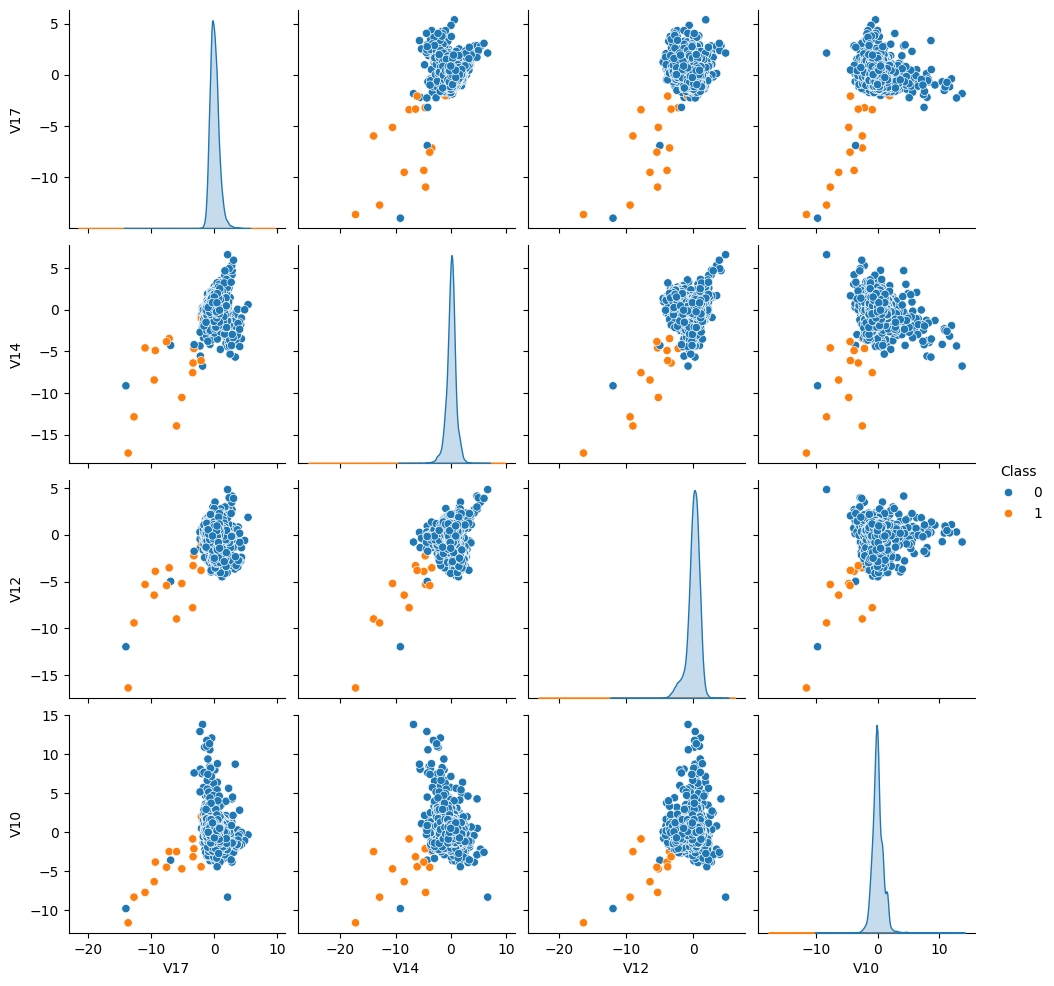

In [61]:
sns.pairplot(
    pairplot_sample[pair_features],
    hue="Class"
)

plt.show()

pairplot of the four most correlated features (V17, V14, V12, V10) — diagonal plots show each feature's distribution, off-diagonal plots show scatter relationships between pairs, colored by Class (blue = 0, orange = 1)

legit transactions (blue) cluster tightly in a dense blob near zero across all feature pairs, while fraud transactions (orange) consistently scatter toward the lower-left / negative values, clearly separated from the main cluster in most scatterplots (e.g. V17 vs V14, V12 vs V10). This visual separation confirms these four features are strong discriminators for fraud, and a model using them together should be able to draw a fairly clean decision boundary, even though no single feature alone fully separates the classes.